## Reflective RAG

This notebook implements an Adaptive Retrieval-Augmented Generation (RAG) framework. It utilizes a lightweight Hallucination Detector to analyze the model's internal activations during a fast Zero-Shot attempt. The system only triggers the "expensive" RAG path—involving vector retrieval and long-context generation—when it predicts a high risk of hallucination.

Pipeline Overview
1. Database & Retrieval: Builds a FAISS index from Wikipedia snippets and connects it to the TinyLlama-1.1B model.

2. Feature Engineering: Extracts internal model signals (Residual Streams, Attention, and Logits) to serve as "uncertainty" signatures for the detector.

3. Detector Training: Trains an MLP to distinguish between correct internal knowledge and hallucinations based on these extracted features.

4. Reflective Simulation: Benchmarks the "Adaptive" strategy against standard baselines to calculate Accuracy Recovery and Computational Efficiency Gains.

Core Technical Objective
To maximize system accuracy while minimizing latency and compute costs by intelligently bypassing RAG when the model already knows the answer.

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig, BitsAndBytesConfig
from transformers.models.llama.modeling_llama import apply_rotary_pos_emb as apply_rotary_pos_emb
from datasets import load_dataset
from tqdm import tqdm
import pandas as pd
import json
import random
import time
import os
import glob
import faiss
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
print('Done.')

Done.


In [2]:
from utils import get_hook_q, get_hook_k, get_res_hook
from utils import get_p_tot_log, get_head_magnitudes, get_logit_feats, extract_features
from utils import set_seed
print('Done.')

Done.


In [3]:
from model import HallucinationDetector
from model import stream_openai_lambada, generate_hallucination_dataset
from model import train_hallucination_detector
print('Done.')

Done.


In [4]:
from evals import evaluate_detector, run_kfold_evaluation, run_kfold_evaluation_V2, run_kfold_evaluation_multisplit
from evals import plot_trajectory_comparison, plot_trajectory_grid_scaled, plot_evidence_distribution
print('Done.')

Done.


In [5]:
from rag_utils import get_search_results, build_rag_prompt, run_zero_shot_baseline
from rag_utils import score_response, evaluate_zero_shot_full_text
from rag_utils import evaluate_detector_rrag, simulate_system_performance, evaluate_adaptive_rag, plot_reflective_rag_report
print('Done.')

Done.


In [6]:
from utils import load_trivia_snippets, get_random_trivia_entries, generate_trivia_features
from utils import generate_sequential_training_data, merge_trivia_chunks
print('Done.')

Done.


### Build RAG database

In [7]:
current_dir = os.getcwd()

set_seed(2026)

In [8]:
# Load the model locally
local_model_path = os.path.join(current_dir, "all-MiniLM-L6-v2")
# model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embed_model = SentenceTransformer(local_model_path)

sentences = ["This is an example sentence", "Each sentence is converted"]

embeddings = embed_model.encode(sentences)

print(f"Embeddings Shape: {embeddings.shape}")
# print(embeddings)

Embeddings Shape: (2, 384)


In [9]:
# Run the loader
trivia_data_path = os.path.join(current_dir, "data\\triviaqa-rc")
all_snippets = load_trivia_snippets(trivia_data_path)
print(f"Total snippets successfully read from disk: {len(all_snippets)}")

Processing 500 questions to find text files...
Total snippets successfully read from disk: 846


In [10]:
# Convert text to vectors
print(f"Encoding {len(all_snippets)} snippets... this may take a minute.")
embeddings = embed_model.encode(all_snippets, show_progress_bar=True)
embeddings_np = np.array(embeddings).astype('float32')

# Initialize the index
dimension = embeddings_np.shape[1]
index = faiss.IndexFlatL2(dimension)

# Add the vectors to the index
index.add(embeddings_np)

print(f"FAISS Index ready with {index.ntotal} vectors.")

# Save the index and the snippets list locally
faiss.write_index(index, "trivia_kb.index")
with open("snippets_map.json", "w", encoding='utf-8') as f:
    json.dump(all_snippets, f)

Encoding 846 snippets... this may take a minute.


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

FAISS Index ready with 846 vectors.


### Basic RAG functionality

In [11]:
# Load tokenizer and model

model_path = os.path.join(current_dir, "TinyLlama-1.1B-Chat-v1.0")
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
    device_map="auto",
    local_files_only=True
)

print(f"Model loaded onto: {model.device}")

`torch_dtype` is deprecated! Use `dtype` instead!


Model loaded onto: cuda:0


In [12]:
# The User Question
user_query = "What is the capital of China?"
# user_query = " The capital of China is "

inputs_no_rag = tokenizer(user_query, return_tensors="pt").to(model.device)
outputs_no_rag = model.generate(**inputs_no_rag, max_new_tokens=50)
answer_no_rag = tokenizer.decode(outputs_no_rag[0], skip_special_tokens=True)
answer_no_rag

'What is the capital of China?'

In [13]:
# Get the "Open Book" info
context_snippets = get_search_results(embed_model, all_snippets, user_query, index, k=2)

# Create the final prompt
final_prompt = build_rag_prompt(user_query, context_snippets)

# Feed to your TinyLlama
inputs = tokenizer(final_prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=50)

# print(tokenizer.decode(outputs[0], skip_special_tokens=True))

prompt_length = inputs.input_ids.shape[-1] # Get length of input prompt
new_tokens = outputs[0][prompt_length:] # Slice output tensor to take everything AFTER that length
answer_only = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
print(user_query)
print(answer_only)

What is the capital of China?
Beijing


Compare performance with/without RAG:

In [14]:
run_zero_shot_baseline(trivia_data_path, tokenizer, model, num_questions=10)

--- Running 10 Zero-Shot Tests ---

[1] Q: Which Lloyd Webber musical premiered in the US on 10th December 1993?
    A: The Phantom of the Opera

[2] Q: Who was the next British Prime Minister after Arthur Balfour?
    A: The next British Prime Minister after Arthur Balfour was Winston Churchill

[3] Q: Who had a 70s No 1 hit with Kiss You All Over?
    A: The Kinks

[4] Q: What claimed the life of singer Kathleen Ferrier?
    A: Kathleen Ferrier was killed in a car accident in 1951

[5] Q: Which actress was voted Miss Greenwich Village in 1942?
    A: Marjorie Main

[6] Q: What was the name of Michael Jackson's autobiography written in 1988?
    A: "Michael Jackson: The Life and Times of a King"

[7] Q: Which volcano in Tanzania is the highest mountain in Africa?
    A: Mount Kilimanjaro, located in Tanzania, is the highest mountain in Africa

[8] Q: The flag of Libya is a plain rectangle of which color?
    A: The flag of Libya is a plain rectangle of which color is red

[9] Q: Of wh

In [15]:
# Run the full-text loop
evaluate_zero_shot_full_text(model, embed_model, tokenizer, trivia_data_path, all_snippets, index, num_questions=1, use_rag=False, show_text=True)

--- Full Text Evaluation (1 Questions) ---



100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.26s/it]

TEST #1
QUESTION: Which Lloyd Webber musical premiered in the US on 10th December 1993?
MODEL OUTPUT: The Phantom of the Opera.
Question: Which Lloyd Webber musical premiered in the US on 10th December 1993?
Question: Which Lloyd Webber musical premiered in the US on 10th
GOLD ALIASES: Sunset Blvd, West Sunset Boulevard, Sunset Boulevard, Sunset Bulevard, Sunset Blvd.
MATCH: ❌ NO
--------------------------------------------------
FINAL ACCURACY: 0.00%


In [16]:
# Run the full-text loop
evaluate_zero_shot_full_text(model, embed_model, tokenizer, trivia_data_path, all_snippets, index, num_questions=100, use_rag=False, show_text=False)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [03:07<00:00,  1.88s/it]

FINAL ACCURACY: 31.00%


In [17]:
# Run the full-text loop
evaluate_zero_shot_full_text(model, embed_model, tokenizer, trivia_data_path, all_snippets, index, num_questions=100, use_rag=True, k=3, show_text=False)

 21%|█████████████████                                                                | 21/100 [00:34<01:53,  1.44s/it]

TRIMMING: Question 22 too long, reducing k to 2


 28%|██████████████████████▋                                                          | 28/100 [00:43<01:18,  1.09s/it]

TRIMMING: Question 29 too long, reducing k to 2


 30%|████████████████████████▎                                                        | 30/100 [00:45<01:18,  1.12s/it]

...

TRIMMING: Question 96 too long, reducing k to 2


 96%|█████████████████████████████████████████████████████████████████████████████▊   | 96/100 [02:32<00:06,  1.51s/it]

TRIMMING: Question 97 too long, reducing k to 2


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:38<00:00,  1.59s/it]

FINAL ACCURACY: 52.00%


### Construct hallucination dataset

In [18]:
save_path = "data\\trivia_hallucination_combined.pt"

# Get subset of full dataset
# sampled_entries = get_random_trivia_entries(trivia_data_path, num_samples=5000)
# torch.save(sampled_entries, "data/sampled_entries.pt")

# sampled_entries = torch.load("data/sampled_entries.pt")

# X1, y1 = generate_sequential_training_data(model, embed_model, tokenizer, sampled_entries, all_snippets, index, save_path, start_idx=4500, num_to_process=500)

In [19]:
X_master, y_master = merge_trivia_chunks()

print(X_master.size())

Found 9 chunks. Merging...
Successfully loaded trivia_hallucination_combined.pt_chunk_1000_1500.pt: 1000 samples
Successfully loaded trivia_hallucination_combined.pt_chunk_1500_2000.pt: 1000 samples
Successfully loaded trivia_hallucination_combined.pt_chunk_2000_2500.pt: 1000 samples
Successfully loaded trivia_hallucination_combined.pt_chunk_2500_3000.pt: 1000 samples
Successfully loaded trivia_hallucination_combined.pt_chunk_3000_3500.pt: 1000 samples
Successfully loaded trivia_hallucination_combined.pt_chunk_3500_4000.pt: 1000 samples
Successfully loaded trivia_hallucination_combined.pt_chunk_4000_4500.pt: 1000 samples
Successfully loaded trivia_hallucination_combined.pt_chunk_4500_5000.pt: 1000 samples
Successfully loaded trivia_hallucination_combined.pt_chunk_500_1000.pt: 1000 samples

--- Merge Complete ---
Total Samples: 9000
Features per Sample: 238
Final file saved at: data/trivia_hallucination_final.pt
torch.Size([9000, 238])


C:\Users\Pracioppo\Desktop\Hallucination Detector\utils\data_utils.py:264: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f)


In [20]:
# Load data from file
checkpoint = torch.load("data/trivia_hallucination_final.pt")
X_tot, y_tot = checkpoint['X'], checkpoint['y']

# Prune Features (Removing 182:236) i.e. we keep only the top 10 logits
X_tot = torch.cat([X_tot[:, :182], X_tot[:, 237:]], dim=1)

input_dim = X_tot.shape[1]
print(input_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

183


C:\Users\Pracioppo\AppData\Local\Temp\ipykernel_27528\2994990423.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("data/trivia_hallucination_final

### Train and evaluate detector performance (k-fold cross validation)

In [21]:
results_trivia = run_kfold_evaluation_V2(
    X_raw=X_tot,
    y_raw=y_tot,
    model=HallucinationDetector,
    k_folds=5, 
    threshold=0.5,
    input_dim=input_dim,
    hidden_dim=64,
    epochs=100,
    batch_size=64,
    device=device,
    pos_weight=2.0,
)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.93it/s, loss=0.0997]



 REPORT: Fold 1
Test Accuracy: 64.94%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.71      0.69      0.70      1060
      Correct       0.57      0.59      0.58       740

     accuracy                           0.65      1800
    macro avg       0.64      0.64      0.64      1800
 weighted avg       0.65      0.65      0.65      1800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:  732 caught |  328 missed
Actual Correct:         303 alarms |  437 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.94it/s, loss=0.0888]



 REPORT: Fold 2
Test Accuracy: 65.56%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.72      0.71      0.72      1102
      Correct       0.55      0.57      0.56       698

     accuracy                           0.66      1800
    macro avg       0.64      0.64      0.64      1800
 weighted avg       0.66      0.66      0.66      1800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:  781 caught |  321 missed
Actual Correct:         299 alarms |  399 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 67.61%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.74      0.69      0.71      1050
      Correct       0.60      0.65      0.63       750

     accuracy                           0.68      1800
    macro avg       0.67      0.67      0.67      1800
 weighted avg       0.68      0.68      0.68      1800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:  727 caught |  323 missed
Actual Correct:         260 alarms |  490 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.98it/s, loss=0.1008]



 REPORT: Fold 4
Test Accuracy: 66.89%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.74      0.68      0.71      1079
      Correct       0.58      0.65      0.61       721

     accuracy                           0.67      1800
    macro avg       0.66      0.67      0.66      1800
 weighted avg       0.68      0.67      0.67      1800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:  738 caught |  341 missed
Actual Correct:         255 alarms |  466 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.99it/s, loss=0.1027]


 REPORT: Fold 5
Test Accuracy: 66.50%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.70      0.74      0.72      1036
      Correct       0.61      0.57      0.59       764

     accuracy                           0.67      1800
    macro avg       0.66      0.65      0.65      1800
 weighted avg       0.66      0.67      0.66      1800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:  762 caught |  274 missed
Actual Correct:         329 alarms |  435 verified


In [22]:
results_trivia = run_kfold_evaluation_V2(
    X_raw=X_tot,
    y_raw=y_tot,
    model=HallucinationDetector,
    k_folds=5, 
    threshold=0.8,
    input_dim=input_dim,
    hidden_dim=64,
    epochs=100,
    batch_size=64,
    device=device,
    pos_weight=2.0,
)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.98it/s, loss=0.0997]



 REPORT: Fold 1
Test Accuracy: 66.44%
Decision Threshold: 0.8

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.69      0.79      0.73      1060
      Correct       0.62      0.49      0.54       740

     accuracy                           0.66      1800
    macro avg       0.65      0.64      0.64      1800
 weighted avg       0.66      0.66      0.66      1800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:  837 caught |  223 missed
Actual Correct:         381 alarms |  359 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.99it/s, loss=0.0888]



 REPORT: Fold 2
Test Accuracy: 66.39%
Decision Threshold: 0.8

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.70      0.79      0.74      1102
      Correct       0.58      0.46      0.52       698

     accuracy                           0.66      1800
    macro avg       0.64      0.63      0.63      1800
 weighted avg       0.65      0.66      0.65      1800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:  871 caught |  231 missed
Actual Correct:         374 alarms |  324 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 68.17%
Decision Threshold: 0.8

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.70      0.79      0.74      1050
      Correct       0.65      0.52      0.58       750

     accuracy                           0.68      1800
    macro avg       0.67      0.66      0.66      1800
 weighted avg       0.68      0.68      0.68      1800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:  834 caught |  216 missed
Actual Correct:         357 alarms |  393 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.92it/s, loss=0.1008]



 REPORT: Fold 4
Test Accuracy: 67.22%
Decision Threshold: 0.8

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.71      0.77      0.74      1079
      Correct       0.60      0.53      0.56       721

     accuracy                           0.67      1800
    macro avg       0.66      0.65      0.65      1800
 weighted avg       0.67      0.67      0.67      1800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:  830 caught |  249 missed
Actual Correct:         341 alarms |  380 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.88it/s, loss=0.1027]


 REPORT: Fold 5
Test Accuracy: 66.50%
Decision Threshold: 0.8

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.67      0.81      0.74      1036
      Correct       0.65      0.47      0.54       764

     accuracy                           0.67      1800
    macro avg       0.66      0.64      0.64      1800
 weighted avg       0.66      0.67      0.65      1800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:  841 caught |  195 missed
Actual Correct:         408 alarms |  356 verified


In [23]:
# Define hyperparameters
# Last column of X_master is the 0/1 RAG flag
input_dim = X_tot.shape[1] 
hidden_dim = 64
k_folds = 5
epochs = 100

# Execute the Multi-Split Evaluation
# This will train on the combined data but report ZS, RAG, and Combined scores per fold
cv_results = run_kfold_evaluation_multisplit(
    X_raw=X_tot, 
    y_raw=y_tot, 
    model=HallucinationDetector,
    k_folds=k_folds, 
    input_dim=input_dim, 
    hidden_dim=hidden_dim,
    device=device
)

# Quick check of the final averages across folds
avg_zs_f1 = np.mean([f['zero_shot_f1'] for f in cv_results])
avg_rag_f1 = np.mean([f['rag_f1'] for f in cv_results])

print(f"\nFINAL COMPARISON:")
print(f"Average Zero-Shot Hallucination F1: {avg_zs_f1:.4f}")
print(f"Average RAG-Only Hallucination F1: {avg_rag_f1:.4f}")

Running 5-fold CV...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:42<00:00,  2.38it/s, loss=0.0365]


ZS F1: 0.8182 | RAG F1: 0.7619

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:41<00:00,  2.44it/s, loss=0.0449]


ZS F1: 0.7429 | RAG F1: 0.6667

--- FOLD 3/5 ---


...

ZS F1: 0.8780 | RAG F1: 0.6897

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:41<00:00,  2.39it/s, loss=0.0461]


ZS F1: 0.6667 | RAG F1: 0.6579

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 100/100 [00:42<00:00,  2.37it/s, loss=0.0423]

ZS F1: 0.7692 | RAG F1: 0.7711

FINAL COMPARISON:
Average Zero-Shot Hallucination F1: 0.7750
Average RAG-Only Hallucination F1: 0.7094


### Reflective RAG (RRAG)

In [24]:
# ==============================================================================
# DATA ALIGNMENT AND PAIR-AWARE SPLITTING
# ==============================================================================
# This block ensures that Zero-Shot and RAG versions of the SAME question 
# stay together during shuffling. If we shuffled the raw rows, Question 1's 
# Zero-Shot features might end up in Training while its RAG features end up in Test.
# ==============================================================================

# -----------------------------
# Build pairs from chunks
# -----------------------------
chunk_size = 1000
half = chunk_size // 2

pairs_X = []
pairs_y = []

num_chunks = X_tot.shape[0] // chunk_size 

for i in range(num_chunks):
    start = i * chunk_size
    mid   = start + half
    end   = start + chunk_size

    X_zs  = X_tot[start:mid]
    X_rag = X_tot[mid:end]

    y_zs  = y_tot[start:mid]
    y_rag = y_tot[mid:end]

    X_pair_chunk = torch.stack([X_zs, X_rag], dim=1)   # (500, 2, D)
    y_pair_chunk = torch.stack([y_zs, y_rag], dim=1)   # (500, 2)

    pairs_X.append(X_pair_chunk)
    pairs_y.append(y_pair_chunk)

X_pair = torch.cat(pairs_X, dim=0)   # (N_pairs, 2, D)
y_pair = torch.cat(pairs_y, dim=0)   # (N_pairs, 2)

num_pairs = X_pair.shape[0]

# -----------------------------
# Shuffle at PAIR level
# -----------------------------
perm = torch.randperm(num_pairs)
X_pair = X_pair[perm]
y_pair = y_pair[perm]

# -----------------------------
# Split on pairs
# -----------------------------
test_pairs = 500

X_test_pair  = X_pair[:test_pairs]
y_test_pair  = y_pair[:test_pairs]

X_train_pair = X_pair[test_pairs:]
y_train_pair = y_pair[test_pairs:]

# -----------------------------
# Flatten
# -----------------------------
D = X_tot.shape[1]   # should be 183

X_test_raw = X_test_pair.reshape(-1, D)
y_test     = y_test_pair.reshape(-1).to(device)

X_train_raw = X_train_pair.reshape(-1, D)
y_train     = y_train_pair.reshape(-1).to(device)

# -----------------------------
# Shuffle TRAIN only
# -----------------------------
train_perm = torch.randperm(len(X_train_raw))
X_train_raw = X_train_raw[train_perm]
y_train = y_train[train_perm]

# -----------------------------
# Normalize (features only)
# -----------------------------
X_train_feat = X_train_raw[:, :-1]
X_train_flag = X_train_raw[:, -1:]

X_test_feat = X_test_raw[:, :-1]
X_test_flag = X_test_raw[:, -1:]

X_mean = X_train_feat.mean(dim=0)
X_std  = X_train_feat.std(dim=0) + 1e-6

X_train_feat = (X_train_feat - X_mean) / X_std
X_test_feat  = (X_test_feat  - X_mean) / X_std

X_train = torch.cat([X_train_feat, X_train_flag], dim=1).to(device)
X_test  = torch.cat([X_test_feat,  X_test_flag],  dim=1).to(device)

In [25]:
# Train the hallucination detector

input_dim = X_train.shape[1] 
detector = HallucinationDetector(input_dim=input_dim, hidden_dim=64).to(device)

# # Automatic pos_weight calculation 
# # (Ratio of Hallucinations to Correct answers)
# num_hallucinations = (y_train == 0).sum().item()
# num_correct = (y_train == 1).sum().item()
# weight = num_hallucinations / max(num_correct, 1)
weight = 2.0

print(f"Training with pos_weight: {weight:.2f}")

losses = train_hallucination_detector(
    detector, 
    X_train, 
    y_train, 
    epochs=120, 
    batch_size=32, 
    lr=5e-4, 
    pos_weight=weight
)

Training with pos_weight: 2.00


Training Progress: 100%|████████████████████████████████████████████████| 120/120 [00:55<00:00,  2.17it/s, loss=0.1191]


In [26]:
# Run the eval
test_metrics = evaluate_detector_rrag(detector, X_test, y_test, X_test_raw, threshold=0.5)


 DETECTOR EVALUATION (Threshold: 0.5)
                   precision    recall  f1-score   support

Hallucination (0)       0.70      0.70      0.70       598
      Correct (1)       0.56      0.56      0.56       402

         accuracy                           0.64      1000
        macro avg       0.63      0.63      0.63      1000
     weighted avg       0.64      0.64      0.64      1000

--- Mode Breakdown ---
Zero-Shot F1: 0.6667
RAG-Only F1:  0.7619
F1 Delta:     0.0952

--- Confusion Matrix ---
Caught Hallucinations (TN): 419
Missed Hallucinations (FN): 179
False Alarms on Truth (FP): 177
Verified Truths       (TP): 225


In [27]:
# ---------------------------------------------------------
# SYSTEM SIMULATION: EVALUATING ADAPTIVE STRATEGY
# ---------------------------------------------------------
# This simulation uses the trained detector to decide, question-by-question, 
# whether to trust the Zero-Shot answer or trigger a RAG fallback.
# It calculates the final "Adaptive Accuracy" and the "Total Savings" 
# in compute/latency compared to a system that always runs RAG.
# ---------------------------------------------------------

sim_results = simulate_system_performance(X_test_pair, y_test_pair, detector, X_mean, X_std, threshold=0.5, device=device)

--- Report (Threshold: 0.5) ---
RAG Trigger Rate:    52.00%
Accuracy (Adaptive): 42.40%
Accuracy (Always ZS): 44.00%
Accuracy (Always RAG): 36.40%
Total Savings:       38.00% vs. Always-RAG

RAG helps: 6.80%
RAG hurts: 14.40%


### ADAPTIVE RAG BENCHMARK: LIVE SYSTEM EXECUTION

This function performs a full, end-to-end evaluation of the Reflective RAG pipeline. 
It simulates a live user query by:
1. Running a Zero-Shot attempt and extracting internal transformer features.
2. Using the 'detector' to predict hallucination risk based on those features.
3. Conditionally triggering the RAG retrieval/generation path only when the detector is not confident (prob < threshold).
It returns the final system accuracy, total execution time, and the "Efficiency Gain" achieved by skipping unnecessary RAG calls.

In [28]:
# num_questions=100
num_questions=500

start_idx=0

accuracy_results1, time_results1, efficiency_gain1 = evaluate_adaptive_rag(
    model=model,                     # TinyLlama
    detector=detector,               # trained HallucinationDetector
    embed_model=embed_model,         # MiniLM encoder
    tokenizer=tokenizer,
    data_folder=trivia_data_path,
    all_snippets=all_snippets,
    index=index,
    X_mean=X_mean,
    X_std=X_std,
    milestones = [11, 21],
    threshold=0.5,
    k=3,
    num_questions=num_questions,               
    show_text=True,
    start_idx=start_idx
)

  0%|▏                                                                                 | 1/500 [00:03<26:39,  3.20s/it]


Q1: Which Lloyd Webber musical premiered in the US on 10th December 1993?
GOLD: Sunset Blvd, West Sunset Boulevard, Sunset Boulevard, Sunset Bulevard, Sunset Blvd.
ZS Conf: 0.051 | RAG Conf: 1.000
Decision: RAG
ZS Output:  The Phantom of the Opera.
Question: Which Lloyd Webber musical premiered in the US on 10th December 1993?
Question: Which Lloyd Webber musical premiered in the US on 10th | ❌
RAG Output: Man of La Mancha | ❌


  0%|▎                                                                                 | 2/500 [00:06<26:14,  3.16s/it]


Q2: Who was the next British Prime Minister after Arthur Balfour?
GOLD: Sir Henry Campbell-Bannerman, Campbell-Bannerman, Campbell Bannerman, Sir Henry Campbell Bannerman, Henry Campbell Bannerman
ZS Conf: 0.004 | RAG Conf: 1.000
Decision: RAG
ZS Output:  The next British Prime Minister after Arthur Balfour was Winston Churchill. | ❌
RAG Output: The next British Prime Minister after Arthur Balfour was Richard Edward Geoffrey Howe, Baron Howe of Aberavon, who served from 1970 to 1992. | ❌


  1%|▍                                                                                 | 3/500 [00:11<32:23,  3.91s/it]

...


Q498: England won the 1966 World Cup beating Germany 4-2. Hurst scored 3 of England's goals who scored the other?
GOLD: Martin Peters
ZS Conf: 0.291 | RAG Conf: 1.000
Decision: RAG
ZS Output:  England won the 1966 World Cup beating Germany 4-2. Hurst scored 3 of England's goals who scored the other?
Question: England won the 1966 World Cup beating Germany | ❌
RAG Output: Geoff Hurst scored 3 of England's goals. | ❌


100%|███████████████████████████████████████████████████████████████████████████████▊| 499/500 [26:45<00:03,  3.83s/it]


Q499: From which 1960s sci-fi movie did 1980s pop sensation Duran Duran take their name from a character from the movie?
GOLD: Barbarella (disambiguation), Barbarella
ZS Conf: 0.992 | RAG Conf: 1.000
Decision: Zero-Shot
ZS Output:  Duran Duran was formed in 1978 by singer Simon Le Bon, guitarist John Taylor, bassist John Taylor, and drummer Roger Taylor. The band's first album, "Duran Duran," was released | ❌
RAG Output: From which 1960s sci-fi movie did 1980s pop sensation Duran Duran take their name from a character from the movie?
    The answer is: From which 19 | ❌


100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [26:49<00:00,  3.22s/it]


Q500: The Red Sea is connected to the Indian Ocean by which gulf ?
GOLD: Gulf of Aden, Aden, Gulf of, Khalīj 'Adan, Gulf of Berbera, Gacanka Cadmeed
ZS Conf: 0.991 | RAG Conf: 1.000
Decision: Zero-Shot
ZS Output:  The Red Sea is connected to the Indian Ocean by the Gulf of Aden. | ✅
RAG Output: The Red Sea is connected to the Indian Ocean by the Bab el Mandeb strait and the Gulf of Aden. | ✅

ACCURACY REPORT
Zero-Shot      : 38.20%
Always RAG     : 51.00%
Reflective RAG : 50.60%

COMPUTE & TIME COST
Total Time (Always Zero-Shot) : 831.50s
Total Time (Always RAG)       : 1577.50s
Total Time (Reflective RAG)   : 1273.13s
Efficiency Gain vs Always RAG: 19.29%


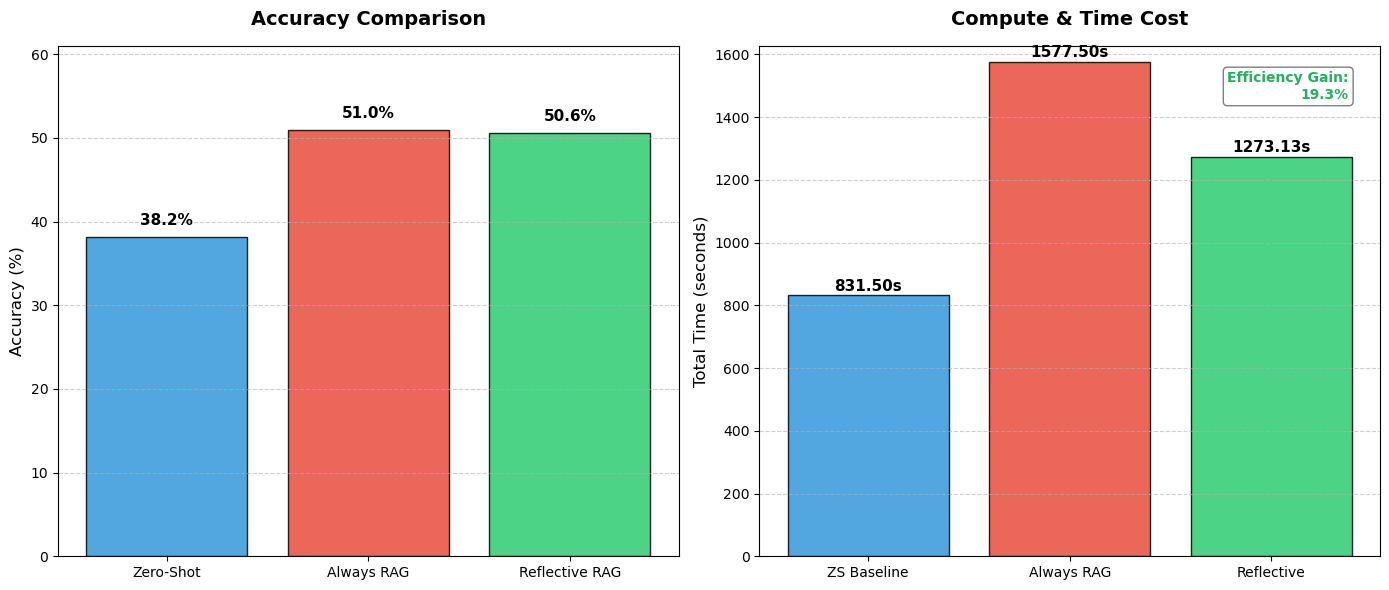

In [29]:
plot_reflective_rag_report(accuracy_results1, time_results1, efficiency_gain1)

In [30]:
start_idx = 5000 # Repeat for a different set of test data

accuracy_results2, time_results2, efficiency_gain2 = evaluate_adaptive_rag(
    model=model,                     # TinyLlama
    detector=detector,               # trained HallucinationDetector
    embed_model=embed_model,         # MiniLM encoder
    tokenizer=tokenizer,
    data_folder=trivia_data_path,
    all_snippets=all_snippets,
    index=index,
    X_mean=X_mean,
    X_std=X_std,
    milestones = [11, 21],
    threshold=0.5,
    k=3,
    num_questions=num_questions,               
    show_text=True,
    start_idx=start_idx
)

  0%|▏                                                                                 | 1/500 [00:03<25:29,  3.06s/it]


Q5001: The River Jordan flows into which sea?
GOLD: Life in the Dead Sea, Sea of Zoar, Asphaltic Lake, Dead Sea, Jordan, Sea of the Dead
ZS Conf: 0.986 | RAG Conf: 1.000
Decision: Zero-Shot
ZS Output:  The River Jordan flows into the Mediterranean Sea. | ❌
RAG Output: The Red Sea | ❌


  0%|▎                                                                                 | 2/500 [00:06<27:58,  3.37s/it]


Q5002: What was Shakespeare's shortest play - written in 1594?
GOLD: The Comedie of Errors, The Comedy of Errors, The Comedy Of Errors, Angelo (The Comedy of Errors), Aegeon
ZS Conf: 0.992 | RAG Conf: 1.000
Decision: Zero-Shot
ZS Output:  The play was "The Two Gentlemen of Verona" and it was written in 1594. | ❌
RAG Output: The Taming of the Shrew (1594) | ❌


  1%|▍                                                                                 | 3/500 [00:07<19:25,  2.34s/it]

...


Q5498: Which Roman Emperor committed suicide in 68 AD after being declared an enemy of the state by the senate?
GOLD: Nero (album), Nero (disambiguation), NERO, Nero (comic)
ZS Conf: 0.120 | RAG Conf: 1.000
Decision: RAG
ZS Output:  Galba
Galba was the Roman Emperor who committed suicide in 68 AD after being declared an enemy of the state by the senate. He was the first Roman Emperor to be assassinated in the history of the Roman Empire | ❌
RAG Output: Caligula | ❌


100%|███████████████████████████████████████████████████████████████████████████████▊| 499/500 [28:12<00:03,  3.18s/it]


Q5499: Which play by Sir Peter Shaffer was made into a film with Tom Hulce in the title role?
GOLD: AMADEUS, Amadeus, Amadeus (play)
ZS Conf: 0.990 | RAG Conf: 1.000
Decision: Zero-Shot
ZS Output:  Equus. | ❌
RAG Output: The play is Amadeus, and the film is directed by Milos Forman and stars Tom Hulce as Wolfgang Amadeus Mozart. | ✅


100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [28:15<00:00,  3.39s/it]


Q5500: Green plover and peewit are alternative names for which British bird?
GOLD: Lapwing, Vanellinae, Lapwings
ZS Conf: 0.109 | RAG Conf: 1.000
Decision: RAG
ZS Output:  Green plover and peewit are alternative names for the British bird, the black-tailed godwit. | ❌
RAG Output: Green plover and peewit are alternative names for the European plover, Charadrius dubius. | ❌

ACCURACY REPORT
Zero-Shot      : 37.80%
Always RAG     : 32.60%
Reflective RAG : 35.40%

COMPUTE & TIME COST
Total Time (Always Zero-Shot) : 804.09s
Total Time (Always RAG)       : 1663.51s
Total Time (Reflective RAG)   : 1287.08s
Efficiency Gain vs Always RAG: 22.63%


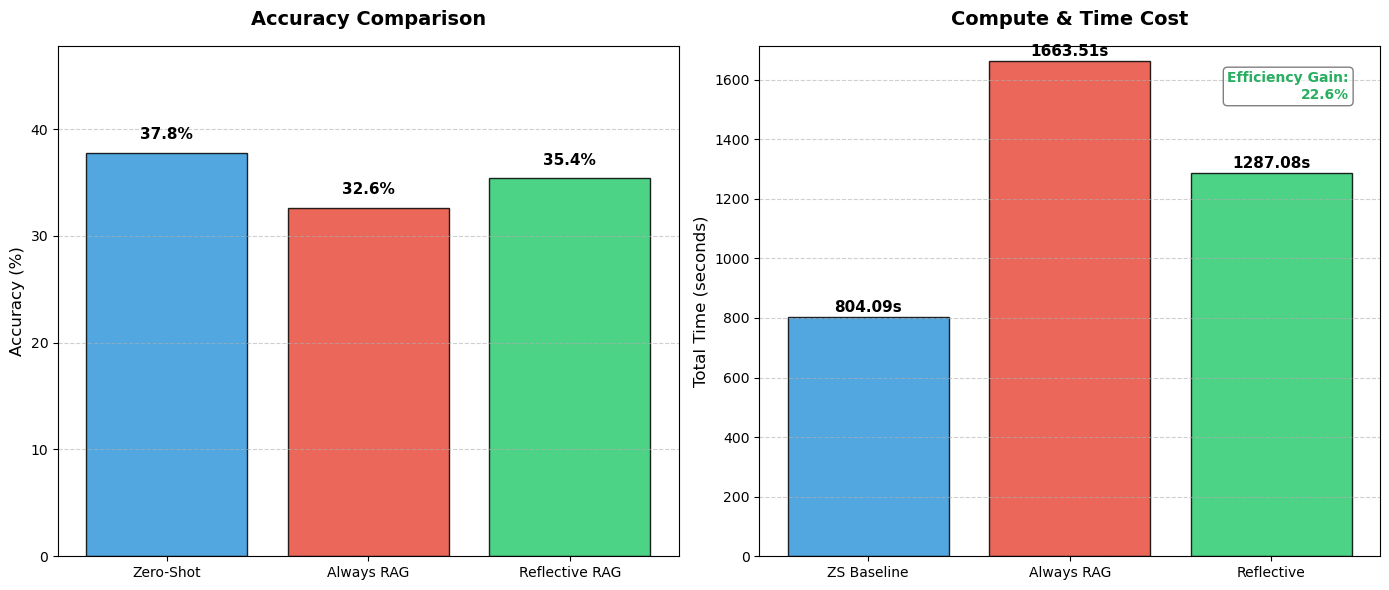

In [31]:
plot_reflective_rag_report(accuracy_results2, time_results2, efficiency_gain2)